In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# 1. IRIS Dataset Classification
# -------------------------------

# Load dataset
iris = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\iris (1).csv")

# Features and target
X_iris = iris.drop("species", axis=1)   # assuming 'species' is the target column
y_iris = iris["species"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Build KNN model (choose k=5 as a common choice)
knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(X_train, y_train)

# Predictions
y_pred_iris = knn_iris.predict(X_test)

# Evaluation
print("IRIS Dataset Results")
print("Accuracy:", accuracy_score(y_test, y_pred_iris))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_iris))
print("Classification Report:\n", classification_report(y_test, y_pred_iris))


# ---------------------------------
# 2. Diabetes Dataset Classification
# ---------------------------------

# Load dataset
diabetes = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\diabetes.csv")

# Features and target
X_diabetes = diabetes.drop("Outcome", axis=1)   # assuming 'Outcome' is the target column
y_diabetes = diabetes["Outcome"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_diabetes, y_diabetes, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build KNN model (choose k=7 for diabetes dataset)
knn_diabetes = KNeighborsClassifier(n_neighbors=7)
knn_diabetes.fit(X_train_scaled, y_train)

# Predictions
y_pred_diabetes = knn_diabetes.predict(X_test_scaled)

# Evaluation
print("\nDiabetes Dataset Results")
print("Accuracy:", accuracy_score(y_test, y_pred_diabetes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_diabetes))
print("Classification Report:\n", classification_report(y_test, y_pred_diabetes))

IRIS Dataset Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Diabetes Dataset Results
Accuracy: 0.6818181818181818
Confusion Matrix:
 [[78 21]
 [28 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76        99
           1       0.56      0.49      0.52        55

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



Best K value: 7
Best Accuracy: 0.9180327868852459


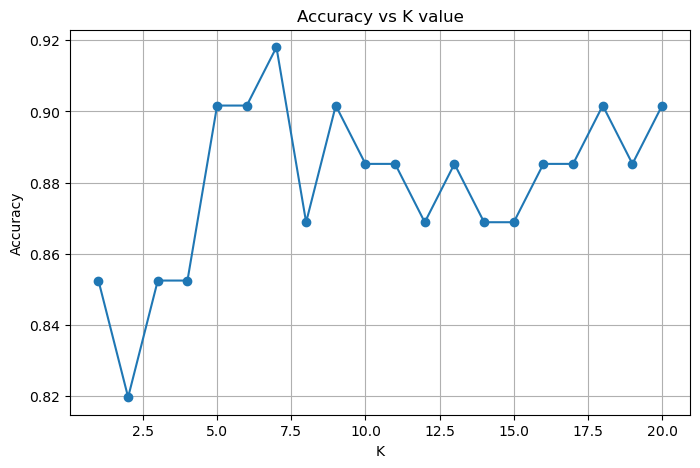

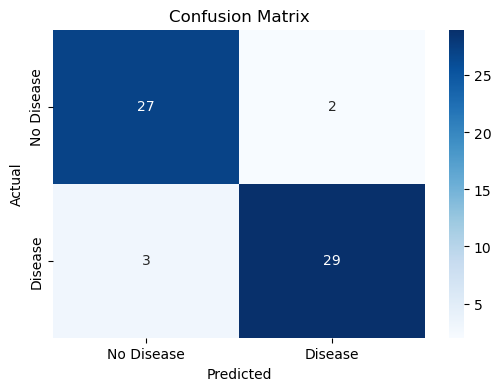

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# Load Heart Dataset
# -------------------------------
heart = pd.read_csv(r"C:\Users\BMSCECSE-SH\Downloads\heart.csv")

# Features and target
X = heart.drop("target", axis=1)   # assuming 'target' is the label column
y = heart["target"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Find Best K
# -------------------------------
accuracy_scores = []
k_values = range(1, 21)  # test k from 1 to 20

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

# Best K
best_k = k_values[np.argmax(accuracy_scores)]
print("Best K value:", best_k)
print("Best Accuracy:", max(accuracy_scores))

# Plot accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Accuracy vs K value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# -------------------------------
# Train Final Model with Best K
# -------------------------------
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Disease","Disease"], yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# Classification Report
# -------------------------------
print("Classification Report:\n", classification_report(y_test, y_pred_best))